In [1]:
cd("/home/ritaferi/Phd/SSDdev/")
using Pkg
Pkg.activate(".")
Pkg.instantiate()

using SolidStateDetectors
using Unitful
using Plots
using LegendHDF5IO

gr()



  Activating project at `~/Phd/SSDdev`


Plots.GRBackend()

In [2]:

sim = Simulation(SSD_examples[:InvertedCoax])
sim.detector = SolidStateDetector(sim.detector, contact_id=2, contact_potential=3500u"V")


________Public Inverted Coax________

---General Properties---
- Precision type: Float32

	_____Semiconductor_____

Semiconductor{Float32} - High Purity Germanium

# Contacts: 2
Contact 1 - 0.0 V - High Purity Germanium
Contact 2 - 3500.0 V - High Purity Germanium

# Passives: 1
Passive Passivation Layer - id -1 - NaN V


In [3]:

calculate_electric_potential!(sim,
    refinement_limits=[0.2, 0.1, 0.05, 0.02],
    verbose=true)



Simulation: Public Inverted Coax
Electric Potential Calculation
Bias voltage: 3500.0 V
φ symmetry: Detector is φ-symmetric -> 2D computation.
Precision: Float32
Device: CPU
Max. CPU Threads: 1
Coordinate system: Cylindrical
N Refinements: -> 4
Convergence limit: 1.0e-7  => 0.00035 V
Initial grid size: (24, 1, 20)

apply initial state : update `sim.electric_potential`, `sim.q_eff_imp`, `sim.q_eff_fix`, `sim.ϵ` and `sim.point_types`
Grid size: (30, 1, 30) - using 1 threads now
Grid size: (40, 1, 50) - using 1 threads now
Grid size: (66, 1, 92) - using 1 threads now
Grid size: (152, 1, 210) - using 1 threads now


In [ ]:
sim.

FieldError: FieldError: type SolidStateDetectors.Semiconductor has no field `d`, available fields: `temperature`, `material`, `impurity_density_model`, `charge_drift_model`, `charge_trapping_model`, `geometry`

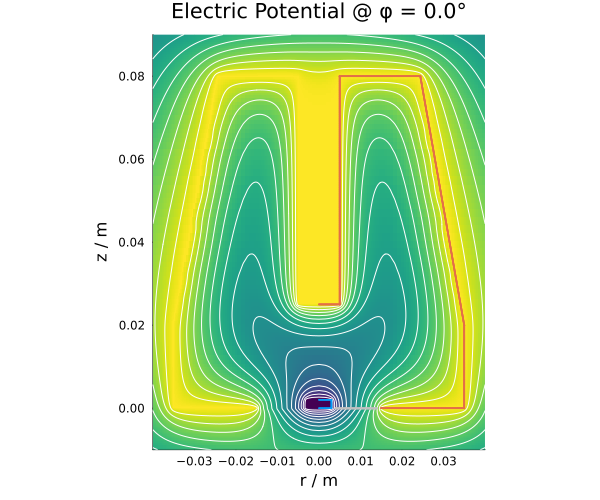

In [100]:
p = plot( sim.electric_potential, 
      contours_equal_potential = true, full_det = true, color = :viridis,show_passives = false,
      linecolor = :white, levels = 15, legend = false, size = (600,500))
plot!(sim.detector, st = :slice, φ = 0)


In [59]:
for i in length(sim.point_types[:,1,1])
    if sim.point_types[i,1,1] != 1.0
        println("trovato un punto non inside")
    end
end

In [77]:
sim.electric_potential.grid

Grid{Float32, 3, Cylindrical}(0.0 .. 0.04 - length = 152, 0.0 .. 0.0 - length = 1, -0.01 .. 0.09 - length = 210)

In [82]:
sim.point_types.data[:, 1, 1]

152-element Vector{UInt8}:
 0x01
 0x01
 0x01
 0x01
 0x01
 0x01
 0x01
 0x01
 0x01
 0x01
    ⋮
 0x01
 0x01
 0x01
 0x01
 0x01
 0x01
 0x01
 0x01
 0x01

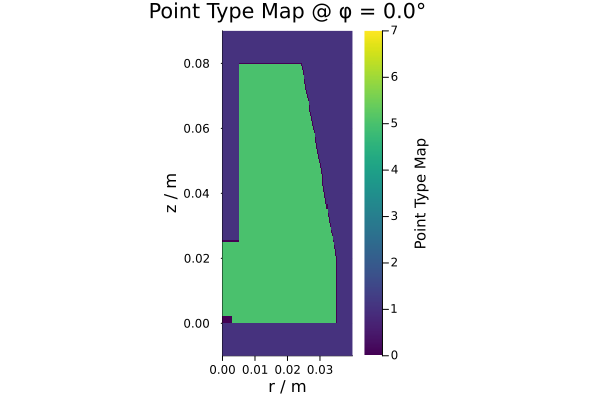

In [84]:
plot(sim.point_types)

In [86]:
sim.electric_potential.grid[1]

0.0 .. 0.04 - length = 152